<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_4%20/Group_Exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 2 – Group Exercise 4 – Clustering (Continuation of Group Exercise 3)**

**Group Exercise 4**

Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset "House Prices - Advanced Regression Techniques"

The dataset contains properties with various environmental variables.

Source:

https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train_house.csv') # RAW Data from GitHub
print("Shape:", df.shape)
#df.head()

Shape: (1460, 81)


## Idea for 2 clusters
Compare and group the relationship between price and year of construction.

In [30]:
# Zwei Features (Preis und Baujahr)
X = df[['YearBuilt', 'SalePrice']].copy()

# Scaling for Cluster-Methods (for equal weighting)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 1. K-Means

In [19]:
# We have set the init value to 'auto' instead of fixed starting points.
kmeansK2 = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeansK2_labels = kmeansK2.fit_predict(X_scaled)

print("Cluster: 2")
print(f"Cluster distribution: {np.bincount(kmeansK2_labels)}")

Cluster: 2
Cluster distribution: [811 649]


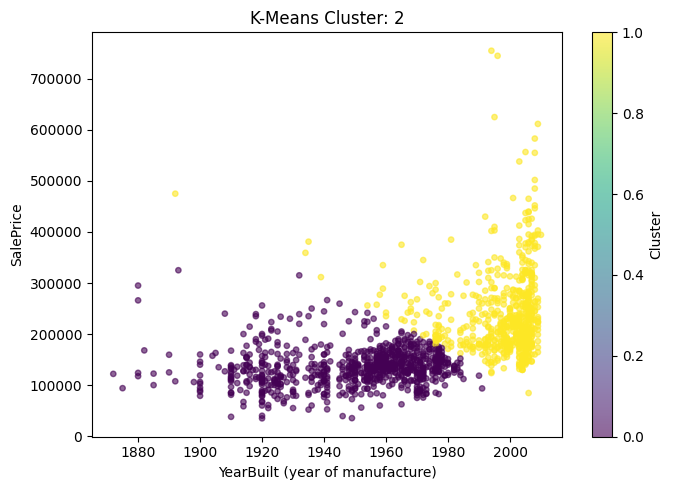

In [24]:
# Visualisation
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X['YearBuilt'], X['SalePrice'], c=kmeansK2_labels, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('YearBuilt (year of manufacture)')
plt.ylabel('SalePrice')
plt.title('K-Means Cluster: 2')
plt.tight_layout()
plt.show()

Interpretation

K-Means divides the houses into two groups. The "dark" cluster contains cheaper but older houses. The "lighter" cluster contains more expensive but predominantly newer houses.

## 2. DBSCAN

We use nearest neighbour to determine the distance. For the minimum samples, we use the number of selected features with additional leeway and set it to 5.

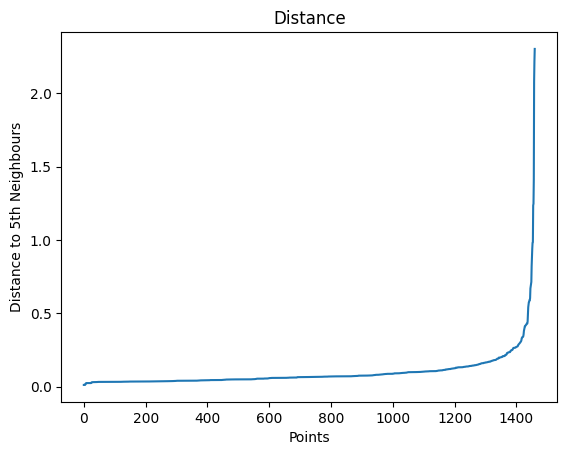

In [39]:
k = 5
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_scaled)
distances, indices = knn.kneighbors(X_scaled)

# Distance to nearest neighbour (sorted)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.xlabel('Points')
plt.ylabel(f'Distance to {k}th Neighbours')
plt.title('Distance')
plt.show()

The elbow is approximately at 0.4.

In [43]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels) - {-1})
n_noise = np.sum(dbscan_labels == -1)

print(f"Bestimmte Parameter:        eps=0.4, min_samples=5")
print(f"Number of clusters found:   {n_clusters}")
print(f"Number of noise points:     {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

Bestimmte Parameter:        eps=0.4, min_samples=5
Number of clusters found:   1
Number of noise points:     23 (1.6%)


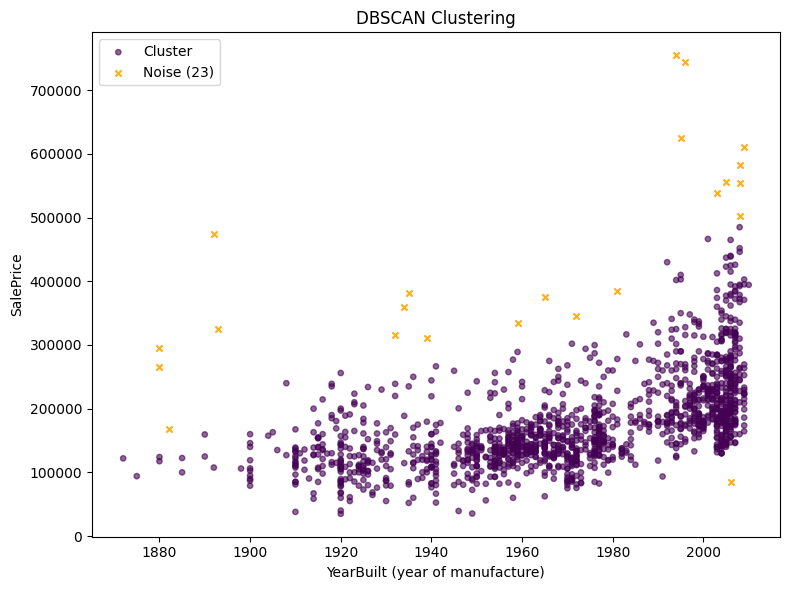

In [56]:
# Visualisation
plt.figure(figsize=(8, 6))
# Noise points
noise = dbscan_labels == -1

plt.scatter(X['YearBuilt'][~noise], X['SalePrice'][~noise],
            c=dbscan_labels[~noise], cmap='viridis', alpha=0.6, s=15, label='Cluster')
plt.scatter(X['YearBuilt'][noise], X['SalePrice'][noise],
            c='orange', alpha=0.9, s=20, marker='x', label=f'Noise ({n_noise})')
plt.xlabel('YearBuilt (year of manufacture)')
plt.ylabel('SalePrice')
plt.title(f'DBSCAN Clustering')
plt.legend()
plt.tight_layout()
plt.show()

Interpretation

DBSCAN has detected a large cluster, with the orange markers representing noise. The noise represents houses with a high price in relation to their year of construction, i.e. outliers. Unlike K-Means, DBSCAN does not draw distinctions between price groups and only displays outliers separately. The advantage is that the cluster size was determined automatically based on the information in the data.

#### Conclusion

DBSCAN is more suitable for this dataset. It detects outliers, which in this context are luxury homes in relation to age. K-Means is particularly suitable here when considering group division in the context of price in relation to age.